Saved plot to /Users/sam/Documents/Oxford/Physics/sloppiness/circadian/mut_project_updates/figures/circ_model/plot_d/plot_d_files/circadian_plotD_meanLZ_vs_mutations.png


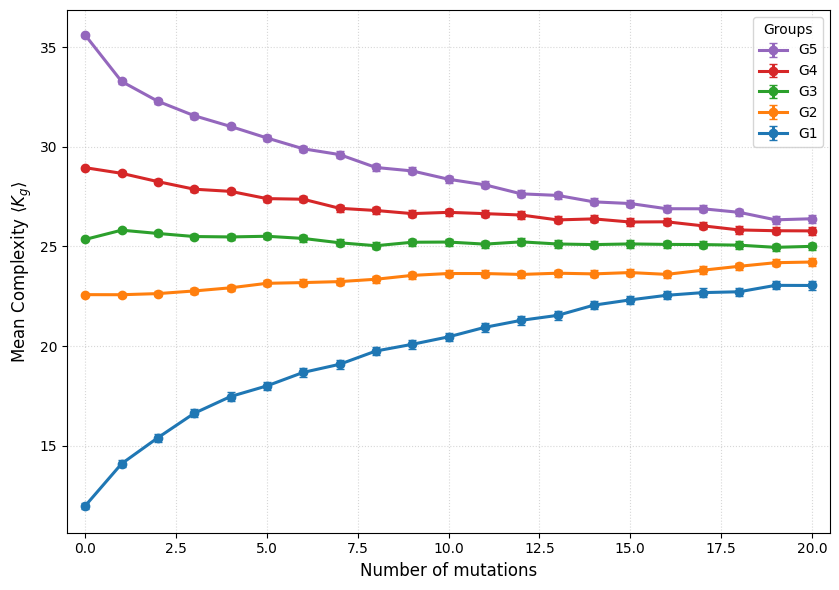

In [1]:
# Plot Circadian model (Plot D) — Mean LZ vs mutation number

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- configure ----------
tables_dir = Path(
    "/Users/sam/Documents/Oxford/Physics/sloppiness/circadian/"
    "mut_project_updates/figures/circ_model/plot_d/plot_d_files/tables"
)

output_dir = tables_dir.parent
out_png = output_dir / "circadian_plotD_meanLZ_vs_mutations.png"

groups = ["G1", "G2", "G3", "G4", "G5"]
max_generation = 20

marker = "o"
linewidth = 2.2
marker_size = 6
# --------------------------------


# Load tables and compute mean + SEM
summary_stats = {}

for group in groups:
    generations = []
    means = []
    sems = []

    for gen in range(0, max_generation + 1):
        table_file = tables_dir / f"{group}_{gen}param_table.txt"

        if table_file.exists():
            df = pd.read_csv(table_file, sep="\t")
            lz_vals = pd.to_numeric(df["complexity_entropy"], errors="coerce").dropna().values

            if len(lz_vals) > 0:
                generations.append(gen)
                means.append(np.mean(lz_vals))
                sems.append(np.std(lz_vals) / np.sqrt(len(lz_vals)))

    summary_stats[group] = {
        "generations": np.array(generations),
        "means": np.array(means),
        "sems": np.array(sems),
    }

# Plot
plt.figure(figsize=(8.5, 6))

for group in groups:
    data = summary_stats[group]
    if len(data["generations"]) == 0:
        continue

    plt.errorbar(
        data["generations"],
        data["means"],
        yerr=data["sems"],
        marker=marker,
        linewidth=linewidth,
        markersize=marker_size,
        capsize=3,
        label=group
    )

# Cosmetics (match your style)
plt.xlabel("Number of mutations", fontsize=12)
plt.ylabel(r"Mean Complexity $\langle K_g \rangle$", fontsize=12)
plt.grid(True, linestyle=":", alpha=0.5)

# Reverse legend order (G5 → G1)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title="Groups", loc="upper right")

# 0.5 tick spacing margin
all_gens = sorted({g for group in summary_stats.values() for g in group["generations"]})
if len(all_gens) > 1:
    spacing = all_gens[1] - all_gens[0]
else:
    spacing = 1.0

plt.xlim(min(all_gens) - 0.5 * spacing,
         max(all_gens) + 0.5 * spacing)

plt.tight_layout()
plt.savefig(out_png, dpi=150)
print(f"Saved plot to {out_png}")
plt.show()